In [55]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 1.0 MB/s eta 0:00:00a 0:00:010m


In [58]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from VAE import VAE 

In [59]:
class PineappleTripletDataset(Dataset):
    def __init__(self, root_dir, train=True, train_ratio=0.8, resize_shape=(256, 256), dataframe=None):
        """
        Args:
            root_dir (string): Directory with images organized in subfolders by class.
            train (bool): Use training split if True, validation split otherwise.
            train_ratio (float): Ratio of training samples (e.g., 0.8 for 80% training).
            resize_shape (tuple): (height, width) for resizing images.
        """
        self.df = dataframe
        self.root_dir = root_dir
        self.train = train
        self.train_ratio = train_ratio
        self.resize_shape = resize_shape

        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.label_to_text = {i: class_name for i, class_name in enumerate(self.classes)}

        self.image_paths, self.labels = self._load_image_paths_and_labels()
        self._split_dataset()

        # Define transform
        self.transform = transforms.Compose([
            transforms.Resize(self.resize_shape),
            transforms.ToTensor(),  # Converts to [0,1] and puts channel first
            # Optional: normalize if pretrained model or standardization is required
            # transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

    def _load_image_paths_and_labels(self):
        image_paths, labels = [], []
        for label, class_name in enumerate(self.classes):
            class_folder = os.path.join(self.root_dir, class_name)
            for img_name in os.listdir(class_folder):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(class_folder, img_name))
                    labels.append(label)
        return image_paths, labels

    def _split_dataset(self):
        total_samples = len(self.image_paths)
        indices = torch.randperm(total_samples).tolist()
        train_size = int(self.train_ratio * total_samples)

        if self.train:
            selected_indices = indices[:train_size]
        else:
            selected_indices = indices[train_size:]

        self.image_paths = [self.image_paths[i] for i in selected_indices]
        self.labels = [self.labels[i] for i in selected_indices]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = self._load_image(img_path)
        
        # Extract the filename
        filename = os.path.basename(img_path)

        # Remove suffix based on type (_fg_ or _bg)
        if '_fg_' in filename:
            base_id = filename.split('_fg_')[0]
        elif '_bg' in filename:
            base_id = filename.replace('_bg.png', '')  # safer than split for bg
        else:
            base_id = filename.replace('.png', '')

        # Assume df is your DataFrame
        if base_id:
            match = self.df[self.df['id'] == base_id]
            if not match.empty:
                count_value = match.iloc[0]['count']
                #print(f"Match found for ID '{base_id}'. Count = {count_value}")
            else:
                #print(f"No match found for ID '{base_id}'.")
                count_value = 0
        else:
            #print("Invalid filename format — cannot extract ID.")
            count_value = 0


        return {
            "image": image,
            "label": label,
            "count": count_value,
            "label_text": self.label_to_text[label]
        }

    def _load_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        return self.transform(image)

In [60]:
def extract_and_visualize_latents(model, test_loader, device='cuda'):
    all_latents = []
    all_labels = []
    all_counts = []

    with torch.no_grad():
        for batch in test_loader:
            input_tensor = batch['image'].to(device)
            labels = batch['label']
            counts = batch['count']  # Assumed to be a list or tensor of same length as batch size

            batch_size, _, height, width = input_tensor.shape
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)

            latent, mean, logvar = model.encoder(input_tensor, noise)
            latent_np = latent.cpu().numpy()

            all_latents.append(latent_np)
            all_labels.extend(labels)
            all_counts.extend(counts)

    all_latents = np.concatenate(all_latents, axis=0)
    print(f"{all_latents.shape[0]} latent vectors extracted")

    reshaped_data = all_latents.reshape(all_latents.shape[0], -1)
    nan_mask = ~np.isnan(reshaped_data).any(axis=1)
    data_cleaned = reshaped_data[nan_mask]
    label_cleaned = np.array(all_labels)[nan_mask]
    count_cleaned = np.array(all_counts)[nan_mask]

    print(f"Cleaned data shape: {data_cleaned.shape}")

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    clustered_data = tsne.fit_transform(data_cleaned)

    unique_labels = np.unique(label_cleaned)
    cmap = plt.get_cmap('tab10')
    label_colors = {label: cmap(i) for i, label in enumerate(unique_labels)}

    plt.figure(figsize=(12, 10))
    for label in unique_labels:
        idxs = label_cleaned == label
        plt.scatter(
            clustered_data[idxs, 0],
            clustered_data[idxs, 1],
            c=[label_colors[label]],
            label=f"Class {label}",
            alpha=0.7
        )

    # Annotate first 100 points with their "count" value
    for i in range(min(100, clustered_data.shape[0])):
        x, y = clustered_data[i]
        count = count_cleaned[i]
        plt.text(x, y, str(count), fontsize=7, alpha=0.6)

    plt.title("t-SNE Clustering of Flattened Latents with Sample Count Labels")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [61]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd

def extract_and_visualize_latents_plotly(model, test_loader, device='cuda'):
    all_latents = []
    all_labels = []
    all_counts = []

    with torch.no_grad():
        for batch in test_loader:
            input_tensor = batch['image'].to(device)
            labels = batch['label']
            counts = batch['count']

            batch_size, _, height, width = input_tensor.shape
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)

            latent, mean, logvar = model.encoder(input_tensor, noise)
            latent_np = latent.cpu().numpy()

            all_latents.append(latent_np)
            all_labels.extend(labels)
            all_counts.extend(counts)

    all_latents = np.concatenate(all_latents, axis=0)
    print(f"{all_latents.shape[0]} latent vectors extracted")

    reshaped_data = all_latents.reshape(all_latents.shape[0], -1)
    nan_mask = ~np.isnan(reshaped_data).any(axis=1)
    data_cleaned = reshaped_data[nan_mask]
    label_cleaned = np.array(all_labels)[nan_mask]
    count_cleaned = np.array(all_counts)[nan_mask]

    print(f"Cleaned data shape: {data_cleaned.shape}")

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    clustered_data = tsne.fit_transform(data_cleaned)

    # Create DataFrame for Plotly
    df = pd.DataFrame({
        'x': clustered_data[:, 0],
        'y': clustered_data[:, 1],
        'label': label_cleaned,
        'count': count_cleaned
    })

    fig = px.scatter(
        df,
        x='x',
        y='y',
        color='label',
        hover_data=['label', 'count'],
        title="Interactive t-SNE Clustering of Latents",
        labels={"x": "t-SNE Component 1", "y": "t-SNE Component 2"},
        opacity=0.7
    )

    fig.update_traces(marker=dict(size=6), selector=dict(mode='markers'))
    fig.update_layout(legend_title_text='Class Label', width=900, height=700)
    fig.show()


In [62]:
def visualize_reconstructions(model, test_set, num_samples=5, device='cuda', img_key="image"):
    """
    Visualizes original and reconstructed images side by side.

    Args:
        model: Trained model with forward() returning reconstruction.
        test_set: Dataset with dicts containing 'image'.
        num_samples: Number of examples to visualize.
        device: Device to run inference on.
        img_key: Key to retrieve image tensor from sample (default: 'image').
    """
    model.eval()
    model.to(device)

    fig = plt.figure(figsize=(4 * num_samples, 8))
    rows, cols = 2, num_samples

    for i in range(cols):
        idx = np.random.randint(len(test_set))
        sample = test_set[idx]
        original_image = sample[img_key]

        if isinstance(original_image, torch.Tensor):
            input_tensor = original_image.unsqueeze(0).to(device)
        else:
            input_tensor = torch.tensor(original_image).unsqueeze(0).to(device)

        with torch.no_grad():
            reconstructed, _, _ = model(input_tensor)

        # Convert to displayable image format
        original_image_disp = (original_image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        reconstructed_disp = (reconstructed.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

        # Plot original
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.set_title("Original")
        ax.imshow(original_image_disp)
        ax.axis('off')

        # Plot reconstructed
        ax = fig.add_subplot(rows, cols, i + 1 + cols)
        ax.set_title("Reconstructed")
        ax.imshow(reconstructed_disp)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [63]:
import pandas as pd

df = pd.read_csv("/home/rtxmsi1/Documents/VAE_training-master/DATASET_VERTICAL_IMAGES_FG_BG_FULL_LABELS.csv")

test_set = PineappleTripletDataset(train=False, 
                                   train_ratio=0.8, 
                                   root_dir="/home/rtxmsi1/Documents/VAE_training-master/VERTICAL_IMAGES_FG_BG_FULL_LABELS",
                                   dataframe=df
                                   )
test_loader = DataLoader(test_set, batch_size=1, shuffle=False, num_workers=2)

In [64]:
test_set.label_to_text

{0: 'backgrounds', 1: 'foregrounds', 2: 'full'}

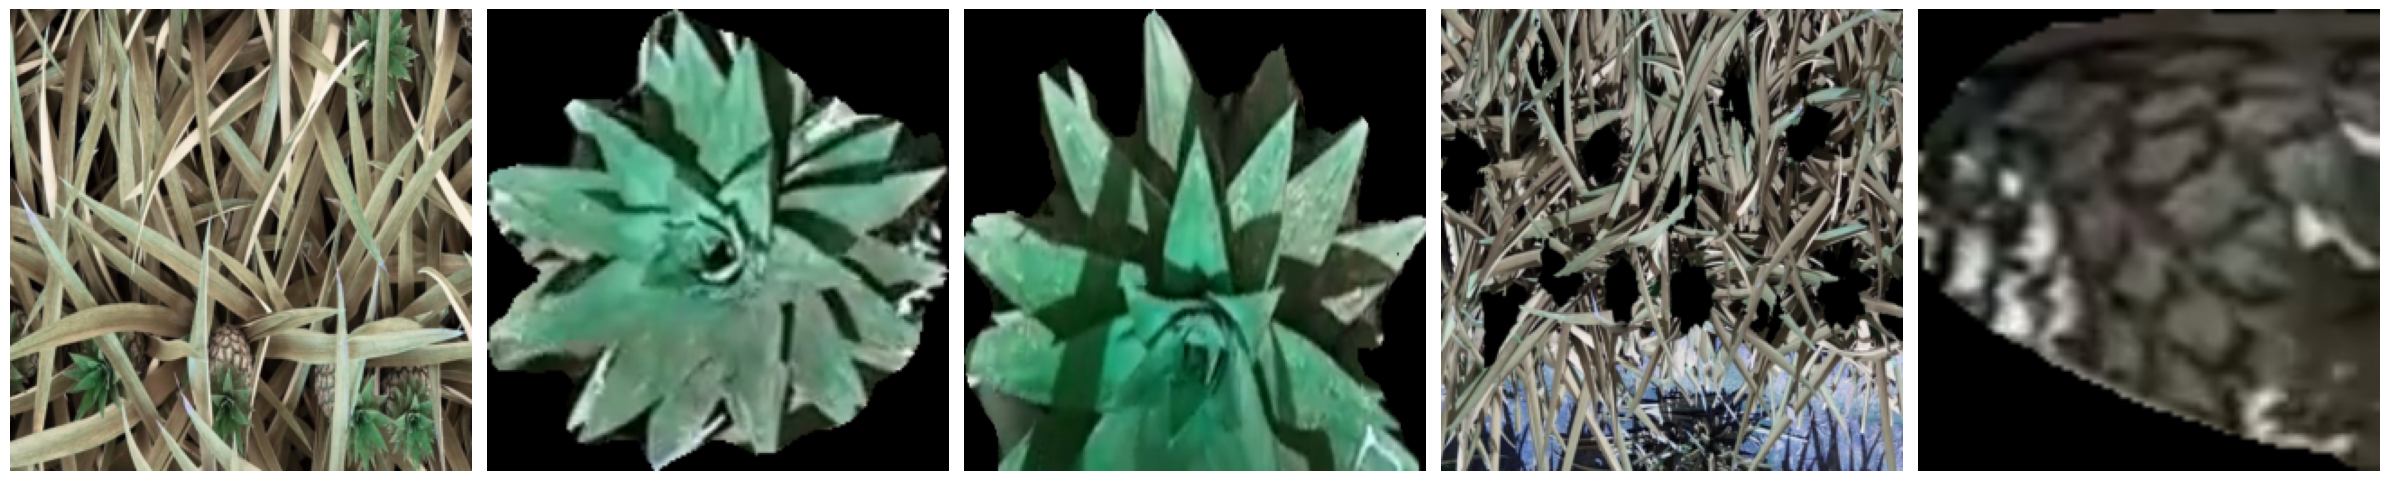

In [65]:
import cv2

fig = plt.figure(figsize=(24, 6))  # Wider and shorter for horizontal layout
rows = 1
columns = 5

for i in range(columns):
    batch = test_set[np.random.randint(len(test_set))]
    img = batch['image'].permute((1, 2, 0)).numpy()  # Convert CHW to HWC
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig.add_subplot(rows, columns, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide axis for better presentation

plt.tight_layout()
plt.show()

In [ ]:
model = VAE().to("cuda")
checkpoint_path = "/home/rtxmsi1/Documents/VAE_training-master/weights_ck_398.pt"  # Replace with your checkpoint file
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [67]:
extract_and_visualize_latents_plotly(model, test_loader)

4485 latent vectors extracted
Cleaned data shape: (4485, 4096)
